# Machine Learning Final Proyect - Nopales
### David Villanueva Guzmán - U6110618
### Alvaro Cámara Guerra - U6110583

### Import Required Libraries

In [170]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

# import torch.multiprocessing as mp
# mp.set_start_method("spawn", force=True)


c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Scripts\python.exe
2.10.0.dev20251210+cu128
True


In [171]:
import torch, kornia, platform

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())


Torch: 2.10.0.dev20251210+cu128
CUDA version in torch: 12.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9


In [172]:
!nvidia-smi


Fri Dec 12 11:49:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.24                 Driver Version: 573.24         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8              3W /  114W |    6097MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [173]:
# !pip install "numpy<2.0" --force-reinstall
# !pip install kornia
import warnings
warnings.filterwarnings("ignore")

In [174]:
# For data processing
# !pip install pandas
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [175]:
# Integrate google drive
# from google.colab import drive
# drive.mount('/content/drive')

### Load the Dataset
Milan Dataset --

In [176]:
# Import Multiclass and Binary annotations
file_path_MC = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_multiclass.csv"
file_path_BIN = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_binary.csv"
# file_path_MC = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/annotations_multiclass.csv'
# file_path_BIN = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/annotations_binary.csv'

# Get dataframes of annotations
df_MC = pd.read_csv(file_path_MC)
df_MC.drop(columns=["Unnamed: 2", "Unnamed: 3"], inplace=True)

print(df_MC.head(10))

  file_prefix printError_physicalDefect
0  001_516_01                       0_0
1  001_516_02                       0_1
2  001_516_03                       0_0
3  001_516_04                       0_0
4  001_516_05                       0_0
5  001_516_06                       0_0
6  001_516_07                       0_0
7  001_516_08                       0_0
8  001_516_09                       0_0
9  001_516_10                       1_0


#### Data Preprocessing

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


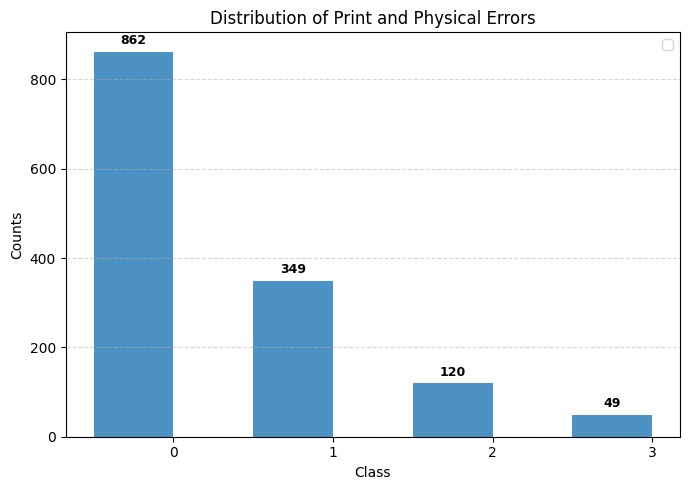

     file_prefix printError_physicalDefect  printError_physicalDefect_int
0     001_516_01                       0_0                              0
1     001_516_02                       0_1                              1
2     001_516_03                       0_0                              0
3     001_516_04                       0_0                              0
4     001_516_05                       0_0                              0
...          ...                       ...                            ...
1375  002_100_11                       0_1                              1
1376  002_100_12                       0_0                              0
1377  002_100_13                       0_0                              0
1378  002_100_14                       0_0                              0
1379  002_100_15                       1_0                              2

[1380 rows x 3 columns]


In [177]:
mapping = {
    "0_0": 0,
    "0_1": 1,
    "1_0": 2,
    "1_1": 3
}

df_MC["printError_physicalDefect_int"] = df_MC["printError_physicalDefect"].map(mapping)

# Count occurrences of each class
print_counts = df_MC["printError_physicalDefect_int"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_MC)

### Binary annotations

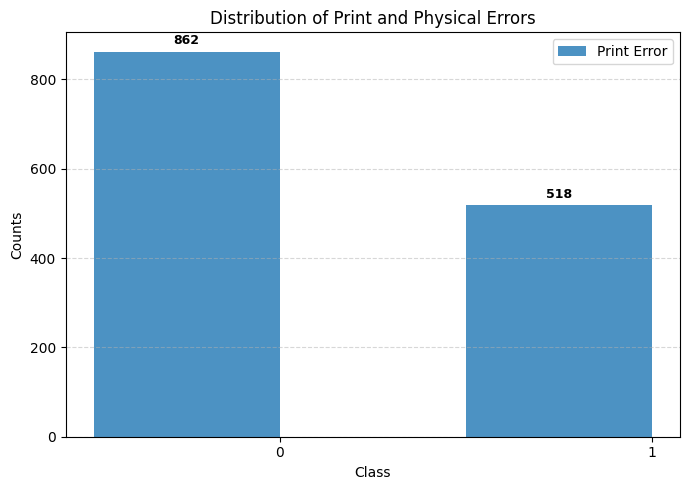

In [178]:
# Lista de strings a buscar en el nombre de la imagen

# Filtrar solo filas donde la segunda columna sea exactamente '0_0'
df_MC["binary"] = (df_MC["printError_physicalDefect_int"] != 0).astype(int)

# Count occurrences of each class
print_counts = df_MC["binary"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, label='Print Error', color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [212]:
# Export the binary annotations
df_MC[["file_prefix", "binary"]].to_csv("output.csv", index=False)

### Data reduction

#### Unzip images inside google drive

In [ ]:
extract_path = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\drive-download-20251113T114126Z-1-001\arrays"

#### Define NPYImageDataset class to load the images

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np

class NPYImageDataset(Dataset):
    def __init__(self, root_dir, names, labels, transform=None):
        """
        root_dir : Folder with .npy files
        names    : List like ['003_045_012', '002_047_12', ...]
        labels   : Array-like with class labels aligned with 'names'
        transform: torchvision transform
        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)                                   # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label


In [182]:
all_names = df_MC["file_prefix"].values      # list of .npy filenames
all_labels = df_MC["binary"].values       # 0 / 1 labels

In [183]:
from sklearn.model_selection import train_test_split

# All indices as ints
indices = np.arange(len(all_names))

# Train set
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

# Validation and test set
temp_labels = all_labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.30,
    stratify=temp_labels,
    random_state=42
)

In [184]:
# Apply split to names and labels
train_names = all_names[train_idx]
val_names   = all_names[val_idx]
test_names  = all_names[test_idx]

train_labels = all_labels[train_idx]
val_labels   = all_labels[val_idx]
test_labels  = all_labels[test_idx]

### Exporting the test dataset into a new directory

In [215]:
# Expor the test dataset into a new folder for testing
import shutil
import pandas as pd
import stat
import time

EXPORT_DIR = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test"
EXPORT_ARRAYS = os.path.join(EXPORT_DIR, "arrays")

# -------- Remove previous export completely --------
def remove_readonly(func, path, exc):
    os.chmod(path, stat.S_IWRITE)
    func(path)

for _ in range(5):
    try:
        shutil.rmtree(EXPORT_DIR, onerror=remove_readonly)
        break
    except PermissionError:
        print("Directory locked, retrying...")
        time.sleep(0.3)

os.makedirs(EXPORT_ARRAYS, exist_ok=True)

print("\nExporting test dataset to:", EXPORT_ARRAYS)

# Folder containing ALL 1380 original .npy images
# Collect paths and labels for CSV
csv_rows = []
for name, label in zip(test_names, test_labels):
    src = os.path.join(extract_path, f"{name}.npy")
    dst = os.path.join(EXPORT_ARRAYS, f"{name}.npy")

    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing .npy file: {src}")

    shutil.copy(src, dst)
    csv_rows.append([name, int(label)])

print(f"Copied {len(csv_rows)} test images.")

# Save labels CSV
csv_path = os.path.join(EXPORT_DIR, "labels.csv")
df = pd.DataFrame(csv_rows, columns=["file_prefix", "binary"])
df.to_csv(csv_path, index=False)

print(f"Saved labels to: {csv_path}")
print("\nTest dataset export complete.\n")


Exporting test dataset to: C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\arrays
Copied 125 test images.
Saved labels to: C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv

Test dataset export complete.



#### Data transforming

In [ ]:
import torchvision.transforms.v2 as transforms
import torch
import kornia.augmentation as K

def scale_image(x):
    return x / 255.0

train_transform = transforms.Compose([
    # Input comes as (C,H,W) torch tensor from NPY
    # Scale to [0,1]
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    # Normalize all 6 channels
    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

val_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])


# kornia_augment = torch.nn.Sequential(
#     # --- Moderate geometric jitter ---
#     K.RandomHorizontalFlip(p=0.4),
#     K.RandomRotation(degrees=3.0, p=0.3),
#     K.RandomAffine(
#         degrees=0,
#         translate=(0.04, 0.04),
#         scale=(0.96, 1.04),
#         p=0.35
#     ),

#     # --- Stronger photometric jitter ---
#     K.RandomBrightness(brightness=(0.90, 1.10), p=0.4),
#     K.RandomContrast(contrast=(0.85, 1.15), p=0.4),
#     # K.RandomGamma(gamma=(0.8, 1.3), p=0.3),

#     # --- Light noise and blur ---
#     K.RandomGaussianNoise(mean=0, std=0.01, p=0.3),
#     K.RandomGaussianBlur(kernel_size=(3,3), sigma=(0.05, 0.25), p=0.2),

#     # --- KEY regularizer: Random erasing ---
#     K.RandomErasing(scale=(0.005, 0.05), ratio=(0.3, 3.3), p=0.35),
# )
kornia_augment = torch.nn.Sequential(
    K.RandomHorizontalFlip(p=0.4),
    K.RandomRotation(degrees=2.0, p=0.3),
    K.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02),
        p=0.3
    ),
    K.RandomBrightness((0.92, 1.08), p=0.4),
    K.RandomContrast((0.88, 1.12), p=0.4),
    K.RandomGaussianNoise(0, 0.008, p=0.25),
    K.RandomGaussianBlur((3,3), (0.05, 0.2), p=0.1),
    K.RandomErasing(scale=(0.003, 0.03), ratio=(0.3, 3.3), p=0.2)
)


In [187]:
train_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=train_names,
    labels=train_labels,
    transform=train_transform
)

val_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=val_names,
    labels=val_labels,
    transform=val_transform
)

test_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=test_names,
    labels=test_labels,
    transform=val_transform
)

In [188]:
batch_size = 8

In [189]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from 4 to 0 for debugging
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # Changed from commented out to 0 for debugging
    pin_memory=True
)

#### Visuazlie a sample

label =  tensor(1)
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 6, 310, 310])
Label: tensor(1)


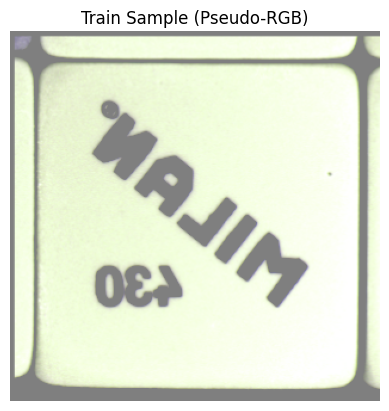

In [190]:
# Visualize ONE sample directly from the DATASET (no batching issues)

import matplotlib.pyplot as plt

# Get one raw sample from the dataset
img, label = train_dataset[0]
print("label = ",label)
img = kornia_augment(img)

print("Type:", type(img))
print("Shape:", img.shape)      # Expected: (1, 6, H, W)
print("Label:", label)

# Undo normalization for visualization
# Since you used: Normalize(mean=[0.5]*6, std=[0.5]*6)
img_vis = img[0, :3] * 0.5 + 0.5   # Take first 3 channels from the first image in batch as pseudo-RGB
img_vis = img_vis.clamp(0, 1)  # Safety clamp

# Show image
plt.imshow(img_vis.permute(1, 2, 0))
plt.title("Train Sample (Pseudo-RGB)")
plt.axis("off")
plt.show()

### Data splitting using multiclass

In [191]:
# def count_labels(loader):
#     count_0 = 0
#     count_1 = 0

#     for _, labels in loader:
#         labels = labels.cpu().numpy()
#         count_0 += (labels == 0).sum()
#         count_1 += (labels == 1).sum()

#     total = count_0 + count_1
#     perc_0 = 100 * count_0 / total
#     perc_1 = 100 * count_1 / total

#     return count_0, count_1, perc_0, perc_1


# # Train
# c0, c1, p0, p1 = count_labels(train_loader)
# print(f"\nTrain -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")

# # Validation
# c0, c1, p0, p1 = count_labels(val_loader)
# print(f"Val   -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")

# # Test
# c0, c1, p0, p1 = count_labels(test_loader)
# print(f"Test  -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")


### Setting the Device

### Define structure

In [192]:
# Import pretrained model ResNet50
import torchvision.models as models
import numpy as np
import torch.nn as nn

# Hyperparameters
dropout_rate = 0.25
num_classes = 2

# Imported model
imported_model = models.resnet34(pretrained=True, progress = True)

# Freeze layers
# frozen_layers = ("conv1", "layer1", "layer2")
frozen_layers = ("layer1")
for name, param in imported_model.named_parameters():
    if name.startswith(frozen_layers):
        param.requires_grad = False
    else:
        param.requires_grad = True

old_weight = imported_model.conv1.weight  # [64, 3, 7, 7]
old_conv = imported_model.conv1
new_conv = nn.Conv2d(
    in_channels=6,             # change from 3 to 6
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias
  )
with torch.no_grad():
    new_conv.weight[:, :3].copy_(old_weight)
    new_conv.weight[:, 3:].copy_(old_weight.clone())
imported_model.conv1 = new_conv

imported_model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(),

    nn.Dropout(dropout_rate),
    nn.Linear(128, 2) 
)


# For resrnet34
layer_groups = {
    "conv1": ["conv1", "bn1"],
    "layer1": ["layer1"],
    "layer2": ["layer2"],
    "layer3": ["layer3"],
    "layer4": ["layer4"],
    "head":   ["fc"],   # classifier
}

### Train the model

### Train and Validation Fucntions

In [193]:
import torch, kornia, platform
# Define device foor runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Torch:", torch.__version__)
print("CUDA version in torch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Kornia:", kornia.__version__)
print("Python:", platform.python_version())
print(device)


Torch: 2.10.0.dev20251210+cu128
CUDA version in torch: 12.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU
Kornia: 0.8.2
Python: 3.11.9
cuda


In [194]:
# ============================================
# FOCAL LOSS - Para datasets desbalanceados
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss para clasificación binaria/multiclase con desbalance.

    Parámetros:
    -----------
    alpha : tensor o None
        Peso para cada clase. Ej: [0.3, 0.7] da más peso a clase 1
    gamma : float
        Factor de enfoque. Típicamente 2.0
        - gamma=0 equivale a CrossEntropyLoss
        - gamma>0 reduce la pérdida para ejemplos bien clasificados
    label_smoothing : float
        Suavizado de etiquetas (0.0 a 0.2 típicamente)
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # será un tensor en GPU
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: logits del modelo, shape (N, C) donde C=num_classes
        targets: etiquetas, shape (N,) con valores 0 o 1
        """
        # Calcular log-softmax para estabilidad numérica
        log_probs = F.log_softmax(inputs, dim=1)

        # Obtener log_prob de la clase correcta para cada muestra
        # targets.unsqueeze(1) -> (N, 1)
        # gather selecciona el log_prob correspondiente a la clase correcta
        ce_loss = F.nll_loss(log_probs, targets, reduction='none')

        # Probabilidad de la clase correcta
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal weight: (1 - pt)^gamma
        focal_weight = (1 - pt) ** self.gamma

        # Aplicar focal weight
        focal_loss = focal_weight * ce_loss

        # Aplicar alpha (peso por clase) si está definido
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        # Reducción
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [195]:
# Optimizer and Criterion
def compute_class_stats_from_loader(loader):
    total_per_class = torch.zeros(2)

    for _, labels in loader:
        for c in [0, 1]:
            total_per_class[c] += (labels == c).sum()

    N0 = int(total_per_class[0].item())  # non-defective
    N1 = int(total_per_class[1].item())  # defective

    return N0, N1


# Class distribution
N0, N1 = compute_class_stats_from_loader(train_loader)
print("Non-defective:", N0)
print("Defective:", N1)

# Calculate the weights
beta = 0.999
w0 = (1 - beta) / (1 - beta**N0)
w1 = (1 - beta) / (1 - beta**N1)

weights = torch.tensor([w0, w1]).to(device)
# criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.035)

# gamma controla cuánto enfocarse en ejemplos difíciles
# gamma=2.0 es el valor típico del paper original
alpha = torch.tensor([0.35, 0.65]).to(device)  # suma = 1.0
criterion = FocalLoss(
    alpha=alpha,
    gamma=2.0,
    label_smoothing=0.05  
)

# Define optimizer
optimizer = torch.optim.AdamW(imported_model.parameters(), lr=1e-4, weight_decay=5e-5)

# Parse model to the GPU
imported_model = imported_model.to(device)

Non-defective: 603
Defective: 363


In [196]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

In [ ]:
#train function
from sklearn.metrics import average_precision_score, f1_score
import torch.nn.functional as F
import numpy as np

def Train(model, train_loader, optimizer, alpha = 0.4):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    # Iterate over all the batches inside the train loader
    for i, (images, labels) in enumerate(train_loader):

        # Move augmented batch to GPU for training
        images = images.to(device)
        labels = labels.to(device)

        # Data augmentation with kornia in the GPU 
        images = kornia_augment(images)

        #mixup
        # images, y_a, y_b, lam = mixup_data(images, labels, alpha = alpha)

        # Initialize backpropagation and optimization
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # If MixUp active, compute mixed loss — works with CrossEntropy
        # if lam is not None:
        #     loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        # else:
        #     loss = criterion(outputs, labels)
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Convert logits → probability of positive class
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Compute AUC-PR for the full epoch
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # AUC-PR
    if len(np.unique(all_labels)) > 1:
        auc_pr = average_precision_score(all_labels, all_probs)
    else:
        auc_pr = 0.0

    # Average loss
    avg_loss = running_loss / len(train_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

#validation function
def Validate(model, val_loader):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits → probability of positive class
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc_pr = average_precision_score(all_labels, all_probs)
    avg_loss = running_loss / len(val_loader)

    # # Binary predictions for F1
    # preds = (all_probs >= 0.5).astype(int)

    # # F1-score
    # f1 = f1_score(all_labels, preds)

    # ----- FIND BEST THRESHOLD FOR F1 -----
    thresholds = np.linspace(0.0, 1.0, 200)
    f1_scores = [
        f1_score(all_labels, (all_probs >= t).astype(int)) 
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])

    return avg_loss, auc_pr, best_f1, best_threshold

In [198]:
import os
import numpy as np

bad_files = []
good = 0

for f in os.listdir(extract_path):
    if not f.lower().endswith(".npy"):
        continue

    full = os.path.join(extract_path, f)

    try:
        arr = np.load(full)
        _ = arr.shape  # force read
        good += 1
    except Exception as e:
        print("❌ Bad file:", full)
        print("   Error:", repr(e))
        bad_files.append(full)

print("\n✅ Good files:", good)
print("❌ Bad files:", len(bad_files))



✅ Good files: 1380
❌ Bad files: 0


In [199]:
print(device)

cuda


In [200]:
num_epochs = 200
patience = 30
min_delta = 1e-3

best_val_aucpr = 0.0
epochs_no_improve = 0
best_model_state = None

In [201]:
print(imported_model)

ResNet(
  (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [202]:
def apply_freezing(model, layer_groups: list[str], layers_to_modify: list[str], freeze_flag: bool):
    """
    freeze_flag: True → freeze layers, False → unfreeze layers
    layers_to_modify: list of keys from layer_groups,
    """

    target_substrings = []
    for key in layers_to_modify:
        target_substrings += layer_groups[key]

    for name, module in model.named_modules():
        if any(substr in name for substr in target_substrings):
            for param in module.parameters():
                param.requires_grad = (not freeze_flag)  # True→freeze means requires_grad=False

def build_optimizer(model, lr: float, wd: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    return torch.optim.AdamW(
        trainable_params,
        lr=lr,
        weight_decay=wd
    )

# optimizer = torch.optim.AdamW(imported_model.parameters(), lr=learning_rate, weight_decay=5e-5)


In [203]:
# Hyperparameters
learning_rate = 1e-4
weight_decay = 1e-4

freeze_schedule = [
    # Phase 1: no freezing at all (warmup)
    (5,  False, [], 1e-4),

    # Phase 2: freeze only layer1 briefly to stabilize early edges
    (10, True,  ["layer1"], 5e-5),

    # Phase 3: full fine-tuning
    (200, False, ["layer1"], 1e-5),
]

# Tracking lists
train_losses = []
val_losses = []
train_aucprs = []
val_aucprs = []
train_f1s = []
val_f1s = []

# Early stopping parameters
best_val_aucpr = 0.0
best_epoch = 0
epochs_no_improve = 0
current_epoch = 0

for block_epochs, freeze_flag, layers_to_modify, lr in freeze_schedule:

    print(f"\n=== New Training Block: {block_epochs} epochs | freeze={freeze_flag} | layers={layers_to_modify} ===")

    # Freeze/unfreeze layers
    apply_freezing(imported_model, layer_groups, layers_to_modify, freeze_flag)

    # Rebuild optimizer to include only unfrozen parameters
    optimizer = build_optimizer(imported_model, lr, weight_decay)

    # Rebuild scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Train inside this block
    for _ in range(block_epochs):

        # Safety break if total num_epochs is reached
        if current_epoch >= num_epochs: break

        # ---- Training ----
        train_loss, train_aucpr, train_f1 = Train(imported_model, train_loader, optimizer)
        val_loss, val_aucpr, val_f1, val_best_th = Validate(imported_model, val_loader)

        # Log metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_aucprs.append(train_aucpr)
        val_aucprs.append(val_aucpr)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        print(
            f"Epoch [{current_epoch+1}/{num_epochs}] "
            f"| Freeze={freeze_flag} | Layers={layers_to_modify} "
            f"| Train Loss={train_loss:.4f} Train AUC={train_aucpr:.4f} "
            f"| Val Loss={val_loss:.4f} Val AUC={val_aucpr:.4f}"
        )

        # ---- EARLY STOPPING ----
        if val_aucpr > best_val_aucpr + min_delta:
            best_val_aucpr = val_aucpr
            best_epoch = current_epoch + 1
            epochs_no_improve = 0
            best_model_state = imported_model.state_dict()
            best_threshold = val_best_th
        else:
            epochs_no_improve += 1
            print(f"  EarlyStopping counter: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered!\n")
            break

        # Step scheduler
        scheduler.step()
        current_epoch += 1

    if epochs_no_improve >= patience:
        break

# Restore best weights
imported_model.load_state_dict(best_model_state)
print(f"\nBest model restored (Epoch {best_epoch} | AUC-PR={best_val_aucpr:.4f})")



=== New Training Block: 5 epochs | freeze=False | layers=[] ===
Epoch [1/200] | Freeze=False | Layers=[] | Train Loss=0.1308 Train AUC=0.4046 | Val Loss=0.0759 Val AUC=0.5326
Epoch [2/200] | Freeze=False | Layers=[] | Train Loss=0.0908 Train AUC=0.4538 | Val Loss=0.0818 Val AUC=0.5708
Epoch [3/200] | Freeze=False | Layers=[] | Train Loss=0.0890 Train AUC=0.4615 | Val Loss=0.0947 Val AUC=0.3311
  EarlyStopping counter: 1/30
Epoch [4/200] | Freeze=False | Layers=[] | Train Loss=0.0890 Train AUC=0.4695 | Val Loss=0.0815 Val AUC=0.5104
  EarlyStopping counter: 2/30
Epoch [5/200] | Freeze=False | Layers=[] | Train Loss=0.0825 Train AUC=0.5717 | Val Loss=0.0751 Val AUC=0.6068

=== New Training Block: 10 epochs | freeze=True | layers=['layer1'] ===
Epoch [6/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.0805 Train AUC=0.5679 | Val Loss=0.0733 Val AUC=0.6061
  EarlyStopping counter: 1/30
Epoch [7/200] | Freeze=True | Layers=['layer1'] | Train Loss=0.0761 Train AUC=0.6276 | Val Loss=0.0

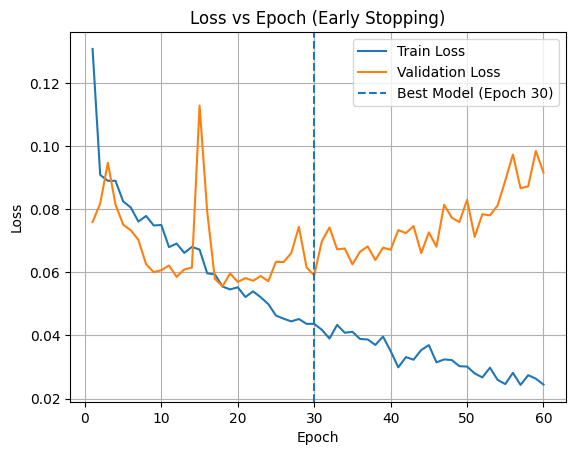

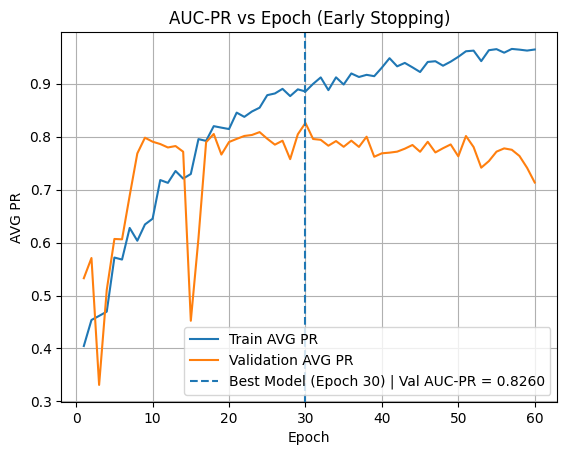

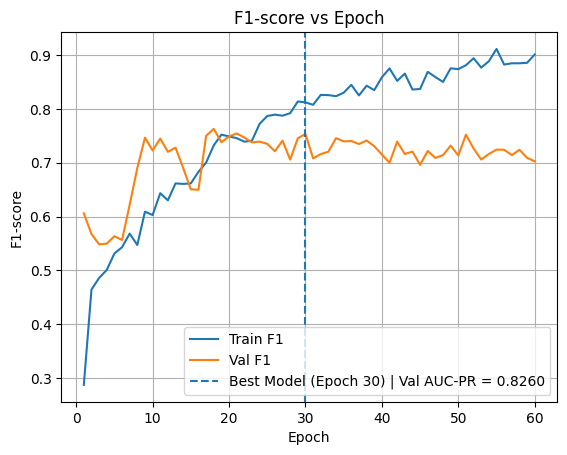

In [204]:
epochs = list(range(1, len(train_losses) + 1))

# -------- LOSS PLOT --------
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch})'
)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- AUC-PR PLOT --------
plt.figure()
plt.plot(epochs, train_aucprs, label='Train AVG PR')
plt.plot(epochs, val_aucprs, label='Validation AVG PR')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel('Epoch')
plt.ylabel('AVG PR')
plt.title('AUC-PR vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- F1 SCORE PLOT --------
plt.figure()
plt.plot(epochs, train_f1s, label="Train F1")
plt.plot(epochs, val_f1s, label="Val F1")
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


AUC-PR: 0.8137


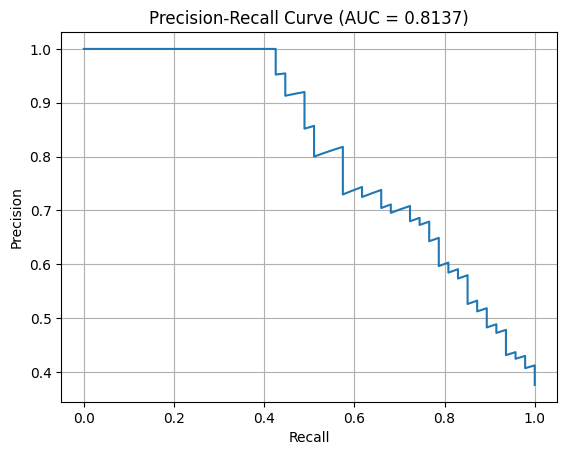

Labels distribution: [78 47]


In [205]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import torch.nn.functional as F

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = imported_model(images)

        # Probabilidad de clase positiva (defecto = clase 1)
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc_pr = average_precision_score(all_labels, all_probs)
print(f"AUC-PR: {auc_pr:.4f}")

# Convert lists to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# Compute AUC-PR
auc_pr = average_precision_score(all_labels, all_probs)

# Plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

print("Labels distribution:", np.bincount(all_labels.astype(int)))


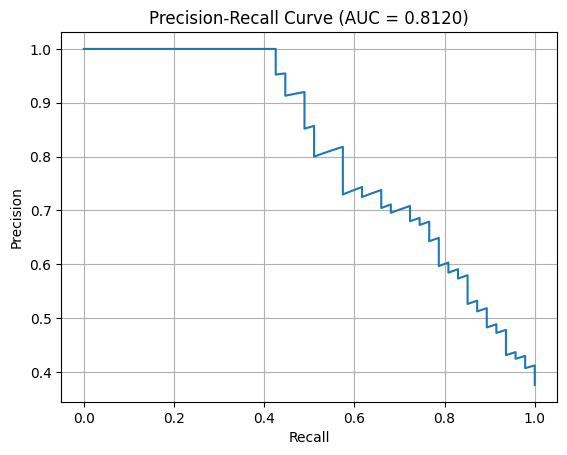

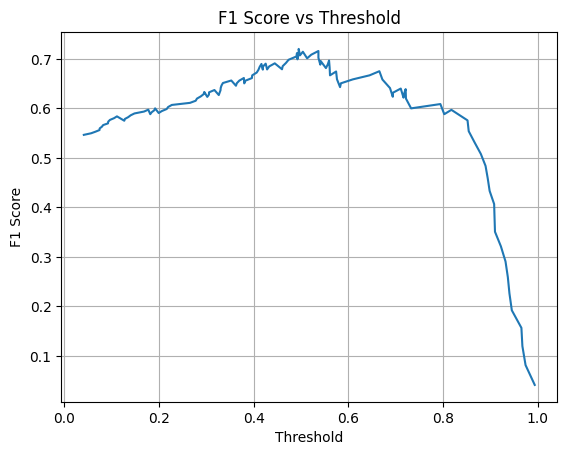

AUC-PR: 0.8120
Best F1: 0.7200
Best Threshold: 0.4951


In [206]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

imported_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = imported_model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

y_scores = torch.cat(all_probs).numpy()
y_true = torch.cat(all_labels).numpy()

# ---- PR Curve ----
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
auc_pr = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

# ---- F1 vs Threshold ----
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

plt.figure()
plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.show()

print(f"AUC-PR: {auc_pr:.4f}")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")


## Saving the model

In [207]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu118
# !pip install onnx onnxruntime onnxscript


In [208]:
print(torch.__version__)

2.10.0.dev20251210+cu128


In [209]:
import torch
import torch.onnx
import torchvision
dummy_input = torch.rand(1, 6, 310, 310).to(device)

import torch
print(torch.__version__)

imported_model.eval()
torch.onnx.export(
    imported_model,
    dummy_input,                     # still use (1,6,H,W)
    "model_v5.onnx",
    opset_version=13,
    input_names=["x"],
    output_names=["linear"],
    dynamic_axes={
        "x": {0: "batch_size"},      # ✅ dynamic batch
        "linear": {0: "batch_size"}  # ✅ dynamic output batch
    },
    export_params=True,
    do_constant_folding=True,
    external_data=False   # export the parameters inside the same file
)

# torch.onnx.export(imported_model, dummy_input, 'model_v2.onnx', opset_version=11)

W1212 12:05:31.073000 39436 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


2.10.0.dev20251210+cu128
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning

Applied 75 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0.dev20251210+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[batch_size,6,310,310]>
            ),
            outputs=(
                %"linear"<FLOAT,[batch_size,2]>
            ),
            initializers=(
                %"fc.0.bias"<FLOAT,[256]>{Tensor(...)},
                %"fc.3.bias"<FLOAT,[128]>{Tensor(...)},
                %"fc.7.weight"<FLOAT,[2,128]>{TorchTensor(...)},
                %"fc.7.bias"<FLOAT,[2]>{TorchTensor<FLOAT,[2]>(Parameter containing: tensor([-0.0081, -0.0272], device='cuda:0', requires_grad=True), name='fc.7.bias')},
                %"conv1.weight"<FLOAT,[64,6,7,7]>{Tensor(...)},
                %"layer1.0.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
              

## Testing the model

In [210]:
import onnx

# Load the ONNX model
loaded_model = onnx.load("model_v5.onnx")

# Check that the IR is well formed
onnx.checker.check_model(loaded_model)

# Print a human readable representation of the graph
print(onnx.helper.printable_graph(loaded_model.graph))

print(loaded_model.graph.input[0].type.tensor_type.shape)

graph main_graph (
  %x[FLOAT, batch_sizex6x310x310]
) initializers (
  %fc.0.bias[FLOAT, 256]
  %fc.3.bias[FLOAT, 128]
  %fc.7.weight[FLOAT, 2x128]
  %fc.7.bias[FLOAT, 2]
  %conv1.weight[FLOAT, 64x6x7x7]
  %layer1.0.conv1.weight[FLOAT, 64x64x3x3]
  %layer1.0.conv2.weight[FLOAT, 64x64x3x3]
  %layer1.1.conv1.weight[FLOAT, 64x64x3x3]
  %layer1.1.conv2.weight[FLOAT, 64x64x3x3]
  %layer1.2.conv1.weight[FLOAT, 64x64x3x3]
  %layer1.2.conv2.weight[FLOAT, 64x64x3x3]
  %layer2.0.conv1.weight[FLOAT, 128x64x3x3]
  %layer2.0.conv2.weight[FLOAT, 128x128x3x3]
  %layer2.0.downsample.0.weight[FLOAT, 128x64x1x1]
  %layer2.1.conv1.weight[FLOAT, 128x128x3x3]
  %layer2.1.conv2.weight[FLOAT, 128x128x3x3]
  %layer2.2.conv1.weight[FLOAT, 128x128x3x3]
  %layer2.2.conv2.weight[FLOAT, 128x128x3x3]
  %layer2.3.conv1.weight[FLOAT, 128x128x3x3]
  %layer2.3.conv2.weight[FLOAT, 128x128x3x3]
  %layer3.0.conv1.weight[FLOAT, 256x128x3x3]
  %layer3.0.conv2.weight[FLOAT, 256x256x3x3]
  %layer3.0.downsample.0.weight[FLOAT

⚠️ No static [1, N] reshape found. Model may already be dynamic.

✅ Saved patched ONNX model as: model_v5_patched.onnx
ONNX Input Name : x
ONNX Output Name: linear

✅ AUC-PR (ONNX, batched): 0.6072


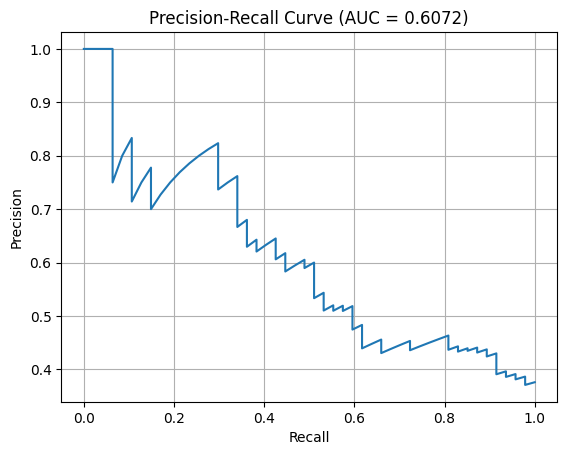


Labels distribution: [78 47]
Probabilities min/max: 0.20232384 0.31781983
Total samples: 125


In [ ]:
import onnx
from onnx import numpy_helper
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

onnx_path_in = "model_v5.onnx"
onnx_path_out = "model_v5_patched.onnx"

model = onnx.load(onnx_path_in)

patched = False

for node in model.graph.node:
    if node.op_type == "Reshape":
        shape_name = node.input[1]   # second input is the shape tensor

        for i, init in enumerate(model.graph.initializer):
            if init.name == shape_name:
                arr = numpy_helper.to_array(init)

                print(f"Found Reshape shape initializer: {shape_name}")
                print("Original shape:", arr)

                if len(arr) == 2 and arr[0] == 1:
                    arr[0] = -1   # ✅ make batch dimension dynamic
                    new_init = numpy_helper.from_array(arr.astype(np.int64), name=shape_name)
                    model.graph.initializer[i].CopyFrom(new_init)

                    print("✅ Patched shape to:", arr)
                    patched = True
                break

if not patched:
    print("⚠️ No static [1, N] reshape found. Model may already be dynamic.")

onnx.save(model, onnx_path_out)
print(f"\n✅ Saved patched ONNX model as: {onnx_path_out}")


# ---------- 2) CREATE ONNX RUNTIME SESSION ----------
ort_session = ort.InferenceSession(
    onnx_path_out,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name

print("ONNX Input Name :", input_name)
print("ONNX Output Name:", output_name)

# ---------- 3) RUN INFERENCE ON TEST LOADER (BATCHED, e.g. batch_size=10) ----------
all_probs = []
all_labels = []

for images, labels in test_loader:
    images_np = images.cpu().numpy()   # (B, 6, 310, 310)
    labels_np = labels.cpu().numpy()

    outputs = ort_session.run(
        [output_name],
        {input_name: images_np}
    )[0]  # (B, 2)

    # Softmax 
    exp_logits = np.exp(outputs)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    probs_pos = probs[:, 1]  # positive class

    all_probs.extend(probs_pos)
    all_labels.extend(labels_np)

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ---------- 4) METRICS & PLOT ----------
auc_pr = average_precision_score(all_labels, all_probs)
print(f"\n✅ AUC-PR (ONNX, batched): {auc_pr:.4f}")

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

print("\nLabels distribution:", np.bincount(all_labels.astype(int)))
print("Probabilities min/max:", all_probs.min(), all_probs.max())
print("Total samples:", len(all_probs))
